# ***Cover Page***

`Data Gathering, Integrity & Fairness Analysis`

Week 20 Final Project

A professional end-to-end data analysis project that transforms raw library records from multiple sources into a reliable, clean, and fairness-aware dataset.



## Prepared by


> Name: ***`Habiba Yasser Ali Mahmoud`***

## Project Introduction

`About the Project`

The City Library — Data Gathering, Integrity & Fairness Analysis project is an end-to-end data analysis project focused on transforming library records from multiple sources into a reliable and analysis-ready dataset.

The project begins with raw data collected from three different sources: a SQLite database, a JSON book catalog, and an HTML page containing Reading Kickoff signups. These sources contain complementary information about library members, book checkouts, and book details.

Throughout the project, the data will be collected, combined, validated, cleaned, and analyzed. The analysis will also examine whether library activity is fairly represented across different neighborhoods.

The final outcome is a trustworthy dataset supported by documented data-integrity decisions, a fairness reflection, and a clear version-control history.

## Project Workflow

Collect → Combine → Validate → Clean → Analyze → Evaluate → Document

## ***Project Objectives***

## ***What Are We Aiming to Achieve?***

The main objective of this project is to transform raw library data from multiple sources into a reliable, consistent, and analysis-ready dataset, while using a structured and transparent data-analysis workflow.

## ***By the end of the project, we aim to:***

`01 — Gather & Combine Data`

Collect data from the SQLite database, JSON book catalog, and HTML Reading Kickoff signups, then combine them into one unified dataset.

`02 — Answer Business Questions`

Use SQL to investigate library borrowing activity, including member borrowing patterns and the most frequently borrowed books.

`03 — Improve Data Integrity`

Identify and address missing values, duplicate records, inconsistent formatting, and orphan records without unnecessarily removing valid information.

`04 — Create a Reliable Dataset`

Produce a cleaned dataset that is consistent, validated, and suitable for further analysis.

`05 — Evaluate Data Fairness`

Compare library members and checkout activity across neighborhoods to identify potential differences in representation.

`06 — Provide Actionable Recommendations`

Use the fairness analysis to suggest a realistic improvement that could help the library provide more balanced services in the future.

`07 — Maintain Version Control`

Document the development process using Git with meaningful commits that represent the major stages of the project.

## ***Data Sources***

## Understanding Where the Data Comes From

Before performing any analysis, it is important to understand the origin, structure, and role of each dataset.

The City Library project provides data from **three different sources**. Each source contains a different part of the information required for the analysis. Our first step is therefore to inspect these sources individually before combining them into a single dataset.

## Source 1 — Library Database

**File:** `library_database.db`  
**Format:** `SQLite Database`

___

## Source 2 — Book Catalog

**File:** `book_catalog.json`  
**Format:** `JSON`

___

## 🌐 Source 3 — Reading Kickoff Signups

**File:** `reading_kickoff_signups.html`  
**Format:** `HTML`


## ***Project Workflow***

## From Raw Data to Reliable Insights

This project follows a structured end-to-end data analysis workflow. Each stage builds on the results of the previous stage, ensuring that the final analysis is based on data that has been properly collected, validated, and cleaned.




###  Stage 1 — `Gather & Combine`

###  Stage 2 — `Inspect & Clean`

### Stage 3 — `Analyze & Evaluate`

### Stage 4 — `Document & Deliver`



# ***Task 1: Data Gathering & Combination***



## ***Building the Foundation for Analysis***

The first stage of the project focuses on gathering information from the three provided sources and transforming it into one unified dataset.

Before combining the data, we will first explore the structure of the library database and answer the required business questions using SQL. We will then integrate the JSON book catalog and the HTML Reading Kickoff signups with the database records.

### ***Task 1 Workflow***

**Database Exploration**
→ **SQL Business Questions**
→ **Members & Checkouts Integration**
→ **Book Catalog Integration**
→ **Reading Kickoff Integration**
→ **Combined Dataset Validation**
→ **Export to CSV**

### ***Expected Output***

At the end of this task, we will produce:

`task1_combined_data.csv`

This file will serve as the input dataset for the data-integrity and cleaning stage in Task 2.

> **Key Principle:** Every integration step will be validated to ensure that relevant records are preserved and that the resulting dataset remains consistent with the original sources.

### ***Database Exploration***

Before writing any SQL queries, we first need to understand the structure of the SQLite database.

This step allows us to identify the available tables, inspect their columns, and understand how the tables are related.

By exploring the database first, we can design accurate queries based on the actual data structure rather than making assumptions.

In [215]:
# Import the libraries required to connect to and inspect the SQLite database.
import sqlite3
import pandas as pd

# Connect to the original library database.
# We keep the source database unchanged and use the connection only for reading
# and analyzing the provided data.
connection = sqlite3.connect("library_database.db")

# Retrieve the names of all tables stored in the database.
# This is our first structural check before writing any business queries.
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
    """,
    connection
)

tables

,name
0,books
1,checkouts
2,members


### ***Inspecting the Database Structure***

After identifying the available tables, the next step is to inspect their structure.

Understanding the columns in each table helps us identify the relationships between members, books, and checkout transactions before constructing our SQL queries.

In [216]:
# Inspect the columns and data types of each table.
# This helps us understand the database schema and identify the keys
# that will be used later when joining tables.

for table_name in tables["name"]:
    print(f"\n{'=' * 60}")
    print(f"TABLE: {table_name}")
    print(f"{'=' * 60}")

    schema = pd.read_sql_query(
        f"PRAGMA table_info({table_name});",
        connection
    )

    display(schema)


TABLE: books


,cid,name,type,notnull,dflt_value,pk
0,0,book_id,INTEGER,0,None,1
1,1,title,TEXT,0,None,0
2,2,author,TEXT,0,None,0



TABLE: checkouts


,cid,name,type,notnull,dflt_value,pk
0,0,checkout_id,INTEGER,0,None,0
1,1,member_id,INTEGER,0,None,0
2,2,book_id,INTEGER,0,None,0
3,3,checkout_date,TEXT,0,None,0
4,4,return_date,TEXT,0,None,0



TABLE: members


,cid,name,type,notnull,dflt_value,pk
0,0,member_id,INTEGER,0,None,1
1,1,first_name,TEXT,0,None,0
2,2,last_name,TEXT,0,None,0
3,3,grade,INTEGER,0,None,0
4,4,neighborhood,TEXT,0,None,0
5,5,membership_status,TEXT,0,None,0
6,6,join_date,TEXT,0,None,0


### ***Understanding Table Relationships***

The database contains three core tables: `members`, `books`, and `checkouts`.

The `checkouts` table acts as the central transaction table. It connects:

- `members` through `member_id`
- `books` through `book_id`

This relationship allows us to connect each borrowing transaction to both the member who borrowed the book and the book that was borrowed.

Understanding these relationships is essential before writing the SQL queries and performing the later data-integration steps.

In [217]:
# Verify the key relationships by checking whether the foreign-key values
# in the checkout table correspond to existing members and books.
# This validation gives us an early view of referential integrity before
# we use these keys in JOIN operations.

member_check = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS total_checkouts,
        COUNT(DISTINCT member_id) AS unique_members
    FROM checkouts;
    """,
    connection
)

book_check = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS total_checkouts,
        COUNT(DISTINCT book_id) AS unique_books
    FROM checkouts;
    """,
    connection
)

print("Checkout → Member relationship:")
display(member_check)

print("Checkout → Book relationship:")
display(book_check)

Checkout → Member relationship:


,total_checkouts,unique_members
0,391,62


Checkout → Book relationship:


,total_checkouts,unique_books
0,391,31


###  ***SQL Business Questions***

With the database structure and relationships now understood, we can begin answering the five business questions defined for the project.

Each question is approached from a business perspective and then translated into SQL logic. The results will be reviewed before moving to the data-combination stage.

The five questions focus on member borrowing activity, author-based book discovery, book popularity, reader activity, and neighborhood checkout activity.

#### How Much Is Each Member Borrowing?



**Business Question**

How much is each member borrowing?

**Approach**

We count the checkout records associated with every registered member.

A `LEFT JOIN` is used intentionally so that members who have not borrowed any books are still included in the result with a count of zero.

In [218]:
# Question 1:
# Count the number of checkout transactions for every registered member.
# LEFT JOIN is used so members with zero checkouts are not excluded.

q1_member_borrowing = pd.read_sql_query(
    """
    SELECT
        m.member_id,
        m.first_name,
        m.last_name,
        COUNT(c.checkout_id) AS checkout_count
    FROM members AS m
    LEFT JOIN checkouts AS c
        ON m.member_id = c.member_id
    GROUP BY
        m.member_id,
        m.first_name,
        m.last_name
    ORDER BY
        m.member_id;
    """,
    connection
)

display(q1_member_borrowing)

,member_id,first_name,last_name,checkout_count
0,1001,Salma,Ibrahim,1
1,1002,Fares,Saleh,2
2,1003,Bassel,Hegazy,9
3,1004,Fares,Wahba,0
4,1005,Youssef,Halim,3
...,...,...,...,...
75,1076,Dina,Wahba,7
76,1077,Lina,Rashad,6
77,1078,Habiba,Osman,0
78,1079,Rana,Osman,10


**Result Interpretation**

The result provides a complete member-level view of borrowing activity. Members with no checkout records are retained because the analysis is intended to represent all registered members, not only active borrowers.

#### Which Books Match a Chosen Author Pattern?

**Business Question**

Which books match a chosen author pattern?

**Selected Pattern**

Authors whose names start with the letter **H**.

**Approach**

The `LIKE` operator is used to search the `author` column.

The pattern `H%` means that the author's name must begin with the letter `H`, followed by any sequence of characters.

In [219]:
# Question 2:
# Find books written by authors whose names start with the letter H.

author_pattern = "H%"

q2_author_pattern = pd.read_sql_query(
    """
    SELECT
        book_id,
        title,
        author
    FROM books
    WHERE author LIKE ?
    ORDER BY
        author,
        title;
    """,
    connection,
    params=(author_pattern,)
)

display(q2_author_pattern)

,book_id,title,author
0,517,Shadows on the Corniche,Hani Nagati
1,518,The Ninth Lighthouse,Hani Nagati
2,515,Songs of the Oasis,Hoda Bakry
3,516,The Beekeeper's Almanac,Hoda Bakry


**Result Interpretation**

The result lists the books whose authors match the selected pattern. Recording the chosen pattern makes the analysis reproducible and makes the selection criteria clear to anyone reviewing the project.

#### What Are the Most Popular Books?

**Business Question**

What are the most popular books?

**Approach**

Book popularity is measured by the number of checkout transactions associated with each book.

The books are ranked from the highest number of checkouts to the lowest, and only the top five are returned.

In [220]:
# Question 3:
# Identify the five most frequently borrowed books.

q3_popular_books = pd.read_sql_query(
    """
    SELECT
        b.book_id,
        b.title,
        COUNT(c.checkout_id) AS checkout_count
    FROM books AS b
    INNER JOIN checkouts AS c
        ON b.book_id = c.book_id
    GROUP BY
        b.book_id,
        b.title
    ORDER BY
        checkout_count DESC,
        b.book_id ASC
    LIMIT 5;
    """,
    connection
)

display(q3_popular_books)

,book_id,title,checkout_count
0,501,The Silver Kite,57
1,507,Fossils and Fireflies,55
2,513,Circuits for Beginners,46
3,519,Kites Over Cairo,38
4,525,Storms and Sailboats,25


**Result Interpretation**

These five titles have the highest number of recorded checkout transactions in the library database, making them the most frequently borrowed books in the available records.

#### Who Are the Most Active Readers?

**Business Question**

Who are the most active readers?

**Approach**

We count the number of checkout transactions associated with each member and rank members from the highest borrowing activity to the lowest.

The analysis returns exactly the top ten members.

In [221]:
# Question 4:
# Identify the ten members with the highest number of checkout transactions.

q4_active_readers = pd.read_sql_query(
    """
    SELECT
        m.member_id,
        m.first_name,
        m.last_name,
        COUNT(c.checkout_id) AS books_borrowed
    FROM members AS m
    INNER JOIN checkouts AS c
        ON m.member_id = c.member_id
    GROUP BY
        m.member_id,
        m.first_name,
        m.last_name
    ORDER BY
        books_borrowed DESC,
        m.member_id ASC
    LIMIT 10;
    """,
    connection
)

display(q4_active_readers)

,member_id,first_name,last_name,books_borrowed
0,1034,Aya,Wahba,25
1,1044,Sherif,Saleh,21
2,1008,Ziad,Saleh,19
3,1010,Nour,Nabil,18
4,1027,Mostafa,Fouad,18
5,1018,Ahmed,Shafik,17
6,1024,Youssef,Hegazy,17
7,1065,Adam,Fahmy,17
8,1030,Reem,Osman,16
9,1047,Sara,Rashad,16


**Result Interpretation**

The result identifies the ten members with the highest recorded borrowing activity. The ranking is based on the number of checkout transactions, with `member_id` used as a secondary ordering rule when borrowing counts are equal.

#### What Does a Neighborhood's Activity Look Like Further Back in Time?

**Business Question**

What does a neighborhood's activity look like further back in time?

**Selected Neighborhood**

**Shubra**

**Approach**

We join checkout records with member records to identify the neighborhood associated with each checkout.

The records are ordered from newest to oldest. The first ten records are skipped, and the next ten records are returned using `OFFSET 10`.

In [222]:
# Question 5:
# Retrieve the second set of ten checkout records for Shubra.
#
# ORDER BY DESC places the newest records first.
# OFFSET 10 skips those first ten records.
# LIMIT 10 returns the next ten records.

selected_neighborhood = "Shubra"

q5_neighborhood_activity = pd.read_sql_query(
    """
    SELECT
        c.checkout_id,
        c.member_id,
        c.book_id,
        c.checkout_date,
        c.return_date
    FROM checkouts AS c
    INNER JOIN members AS m
        ON c.member_id = m.member_id
    WHERE m.neighborhood = ?
    ORDER BY
        c.checkout_date DESC
    LIMIT 10 OFFSET 10;
    """,
    connection,
    params=(selected_neighborhood,)
)

display(q5_neighborhood_activity)

,checkout_id,member_id,book_id,checkout_date,return_date
0,9382,1076,507,2025-02-26,2025-03-08
1,9368,1079,525,2025-02-12,2025-03-10
2,9345,1075,507,2025-02-03,2025-03-01
3,9352,1076,501,2025-02-02,None
4,9359,1077,501,2025-01-26,None
5,9363,1079,507,2024-12-23,2025-01-15
6,9355,1075,515,2024-11-10,2024-12-02
7,9343,1075,529,2024-10-04,2024-10-14
8,9344,1076,507,2024-09-12,None
9,9364,1077,513,2024-08-18,2024-09-07


**Result Interpretation**

This result represents the second set of ten checkout records for the selected neighborhood, after the ten most recent records have been skipped. Ordering by checkout date from newest to oldest keeps the selection consistent with the project requirement.

#### Combining the Three Data Sources

After answering the five SQL business questions, we now move to the second half of Task 1: building one unified dataset from the three provided sources.

The combination is performed in three controlled stages:

1. Members + Checkouts
2. Book Catalog
3. Reading Kickoff Checkouts

At each stage, the resulting structure and record count are checked before continuing.

### Stage 1: Members + Checkouts

The first integration stage connects every checkout with the member who made it.

The checkout table is used as the transaction base so that checkout records are not unintentionally lost.

In addition to the member information, we calculate the total number of books borrowed by each member and attach that value to the combined checkout records.

In [223]:
# Load the three database tables into Pandas.
# From this point, the combination work is performed with Pandas.

members_df = pd.read_sql_query(
    "SELECT * FROM members;",
    connection
)

books_df = pd.read_sql_query(
    "SELECT * FROM books;",
    connection
)

checkouts_df = pd.read_sql_query(
    "SELECT * FROM checkouts;",
    connection
)

print("Members shape:", members_df.shape)
print("Books shape:", books_df.shape)
print("Checkouts shape:", checkouts_df.shape)

Members shape: (80, 7)
Books shape: (32, 3)
Checkouts shape: (391, 5)


In [224]:
# Calculate each member's total borrowing activity.
# This count is based on checkout transactions.

member_borrowing_totals = (
    checkouts_df
    .groupby("member_id")
    .size()
    .rename("total_books_borrowed")
    .reset_index()
)

display(member_borrowing_totals.head())

,member_id,total_books_borrowed
0,1001,1
1,1002,2
2,1003,9
3,1005,3
4,1006,1


In [225]:
# Merge member information into every checkout.
# many_to_one means:
# - many checkout rows may belong to one member
# - each member_id should identify one member record

combined_members_checkouts = checkouts_df.merge(
    members_df,
    on="member_id",
    how="left",
    validate="many_to_one"
)

# Add the member's total borrowing count.
combined_members_checkouts = combined_members_checkouts.merge(
    member_borrowing_totals,
    on="member_id",
    how="left",
    validate="many_to_one"
)

# Validate that no checkout rows were lost.
assert len(combined_members_checkouts) == len(checkouts_df)

print("Original checkout rows:", len(checkouts_df))
print("After member integration:", len(combined_members_checkouts))
print("✅ Validation passed: checkout count is unchanged.")

display(combined_members_checkouts.head())

Original checkout rows: 391
After member integration: 391
✅ Validation passed: checkout count is unchanged.


,checkout_id,member_id,book_id,checkout_date,return_date,first_name,last_name,grade,neighborhood,membership_status,join_date,total_books_borrowed
0,9263,1047,517,2024-10-21,2024-11-07,Sara,Rashad,NaN,Heliopolis,Inactive,2024-06-25,16
1,9340,1072,513,2025-08-24,2025-09-01,Seif,Zaki,9.0,Zamalek,Active,2025-10-21,14
2,9231,1053,523,2024-02-04,2024-02-16,Adam,Shafik,9.0,Heliopolis,Active,2024-01-03,5
3,9129,1032,513,2025-06-21,2025-06-29,Nada,Zaki,7.0,Nasr City,Active,2025-10-19,6
4,9370,1079,511,2025-11-11,2025-12-03,Rana,Osman,8.0,Shubra,Active,2024-10-27,10


### Stage 2: Book Details

The second stage enriches each checkout with additional book information from the JSON catalog.

The catalog is loaded using `pd.read_json()` and merged through `book_id`.

Because this stage adds information rather than creating new checkout events, the number of checkout records must remain unchanged.

In [226]:
# Load the JSON book catalog.
book_catalog_df = pd.read_json("book_catalog.json")

print("Book catalog shape:", book_catalog_df.shape)
display(book_catalog_df.head())

Book catalog shape: (32, 5)


,book_id,genre,pages,publication_year,publisher
0,501,Adventure,128,2017.0,Nile Press
1,502,Adventure,109,2018.0,Delta House
2,503,Historical,259,NaN,Nile Press
3,504,Science,319,2009.0,Cairo Young Readers
4,505,Historical,216,2024.0,Oasis Books


In [227]:
# Merge the JSON catalog into the current combined dataset.
# many_to_one ensures that each book_id matches at most one catalog row.
# The merge indicator lets us verify whether every database checkout
# found a corresponding catalog record.

combined_with_books = combined_members_checkouts.merge(
    book_catalog_df,
    on="book_id",
    how="left",
    validate="many_to_one",
    indicator=True
)

print("Book catalog merge status:")
display(combined_with_books["_merge"].value_counts())

# Every database checkout should have matching book details.
assert (combined_with_books["_merge"] == "both").all()

# Remove the temporary validation column.
combined_with_books = combined_with_books.drop(columns="_merge")

# Verify that the number of checkout records has not changed.
assert len(combined_with_books) == len(combined_members_checkouts)

print("✅ Validation passed: book integration did not change checkout count.")

display(combined_with_books.head())

Book catalog merge status:


,count
_merge,
both,391
left_only,0
right_only,0


✅ Validation passed: book integration did not change checkout count.


,checkout_id,member_id,book_id,checkout_date,return_date,first_name,last_name,grade,neighborhood,membership_status,join_date,total_books_borrowed,genre,pages,publication_year,publisher
0,9263,1047,517,2024-10-21,2024-11-07,Sara,Rashad,NaN,Heliopolis,Inactive,2024-06-25,16,Mystery,338,2015.0,Delta House
1,9340,1072,513,2025-08-24,2025-09-01,Seif,Zaki,9.0,Zamalek,Active,2025-10-21,14,Science,294,2021.0,Oasis Books
2,9231,1053,523,2024-02-04,2024-02-16,Adam,Shafik,9.0,Heliopolis,Active,2024-01-03,5,Historical,276,2018.0,Oasis Books
3,9129,1032,513,2025-06-21,2025-06-29,Nada,Zaki,7.0,Nasr City,Active,2025-10-19,6,Science,294,2021.0,Oasis Books
4,9370,1079,511,2025-11-11,2025-12-03,Rana,Osman,8.0,Shubra,Active,2024-10-27,10,Historical,117,2016.0,Nile Press


### Stage 3: Reading Kickoff Checkouts

The final source is the Reading Kickoff HTML table.

These checkout records were recorded separately from the main library database, so they must be added to the unified dataset.

The HTML source contains `Member ID`, `Book ID`, and `Checkout Date`. It does not contain a return date because the page states that these books were not due back during the recorded period.

We will standardize its column names, enrich the records with the same member and book information used by the database records, and then append them to the combined dataset.

In [228]:
# Read the first HTML table using Pandas.
reading_kickoff_df = pd.read_html("reading_kickoff_signups.html")[0]

print("Original HTML columns:")
print(reading_kickoff_df.columns.tolist())

display(reading_kickoff_df.head())

Original HTML columns:
['Member ID', 'Book ID', 'Checkout Date']


,Member ID,Book ID,Checkout Date
0,1026,522,2025-07-11
1,1049,520,2025-07-11
2,1062,525,2025-07-05
3,1065,520,2025-07-07
4,1104,515,2025-07-07


In [229]:
# Standardize the HTML column names so they match the database structure.

reading_kickoff_df = reading_kickoff_df.rename(
    columns={
        "Member ID": "member_id",
        "Book ID": "book_id",
        "Checkout Date": "checkout_date"
    }
)

# Add the return_date column because the HTML source does not provide it.
# The source explains that these books were not due back during this period.
reading_kickoff_df["return_date"] = pd.NA

# Reorder the columns to match the database checkout structure.
reading_kickoff_df = reading_kickoff_df[
    [
        "member_id",
        "book_id",
        "checkout_date",
        "return_date"
    ]
]

display(reading_kickoff_df.head())

print("Reading Kickoff records:", len(reading_kickoff_df))

,member_id,book_id,checkout_date,return_date
0,1026,522,2025-07-11,<NA>
1,1049,520,2025-07-11,<NA>
2,1062,525,2025-07-05,<NA>
3,1065,520,2025-07-07,<NA>
4,1104,515,2025-07-07,<NA>


Reading Kickoff records: 26


In [230]:
# Add member information to the Reading Kickoff records.
#
# LEFT JOIN is intentional:
# Task 2 will later deal with orphan member IDs.
# At this stage, we preserve every Reading Kickoff checkout.

reading_kickoff_enriched = reading_kickoff_df.merge(
    members_df,
    on="member_id",
    how="left",
    validate="many_to_one"
)

# Add the member's borrowing count from the database checkout history.
reading_kickoff_enriched = reading_kickoff_enriched.merge(
    member_borrowing_totals,
    on="member_id",
    how="left",
    validate="many_to_one"
)

# Members without database checkout history receive zero.
reading_kickoff_enriched["total_books_borrowed"] = (
    reading_kickoff_enriched["total_books_borrowed"]
    .fillna(0)
    .astype(int)
)

# Add book metadata from the JSON catalog.
reading_kickoff_enriched = reading_kickoff_enriched.merge(
    book_catalog_df,
    on="book_id",
    how="left",
    validate="many_to_one"
)

display(reading_kickoff_enriched.head())

,member_id,book_id,checkout_date,return_date,first_name,last_name,grade,neighborhood,membership_status,join_date,total_books_borrowed,genre,pages,publication_year,publisher
0,1026,522,2025-07-11,<NA>,Nada,Saleh,7.0,Nasr City,inactive,2023-11-16,3,Mystery,104,2016.0,Cairo Young Readers
1,1049,520,2025-07-11,<NA>,Ahmed,Gamal,6.0,Heliopolis,Active,2023-06-10,1,Science Fiction,136,2009.0,Oasis Books
2,1062,525,2025-07-05,<NA>,Tarek,Adel,7.0,Zamalek,Active,2023-01-22,7,Adventure,297,2015.0,Oasis Books
3,1065,520,2025-07-07,<NA>,Adam,Fahmy,6.0,Zamalek,Active,2025-07-12,17,Science Fiction,136,2009.0,Oasis Books
4,1104,515,2025-07-07,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,0,Poetry,316,2022.0,Cairo Young Readers


### Aligning the Two Checkout Sources

Before appending the Reading Kickoff records to the database checkouts, both datasets need to use the same column structure.

The goal is to make the two groups compatible without inventing or altering source information unnecessarily.

In [231]:
# Make sure both datasets have the same column names.
# Database checkout records contain checkout_id.
# Reading Kickoff does not provide one, so we keep the field empty
# rather than inventing an identifier that did not exist in the source.

reading_kickoff_enriched["checkout_id"] = pd.NA

# Match the exact column order of the database-based dataset.
reading_kickoff_enriched = reading_kickoff_enriched[
    combined_with_books.columns
]

print("Database-based columns:")
print(combined_with_books.columns.tolist())

print("\nReading Kickoff columns:")
print(reading_kickoff_enriched.columns.tolist())

assert list(combined_with_books.columns) == list(
    reading_kickoff_enriched.columns
)

print("\n✅ Validation passed: both sources have the same structure.")

Database-based columns:
['checkout_id', 'member_id', 'book_id', 'checkout_date', 'return_date', 'first_name', 'last_name', 'grade', 'neighborhood', 'membership_status', 'join_date', 'total_books_borrowed', 'genre', 'pages', 'publication_year', 'publisher']

Reading Kickoff columns:
['checkout_id', 'member_id', 'book_id', 'checkout_date', 'return_date', 'first_name', 'last_name', 'grade', 'neighborhood', 'membership_status', 'join_date', 'total_books_borrowed', 'genre', 'pages', 'publication_year', 'publisher']

✅ Validation passed: both sources have the same structure.


### Create the Final Combined Dataset

The three-source integration is now complete.

The database checkout records enriched with member and book information are combined with the Reading Kickoff records.

Before saving the final dataset, we will check its shape, columns, and sample records as required by the project.

In [232]:
# Combine the database-based checkout records with the Reading Kickoff records.

task1_combined_data = pd.concat(
    [
        combined_with_books,
        reading_kickoff_enriched
    ],
    ignore_index=True
)

# Expected total = database checkouts + Reading Kickoff checkouts.
expected_rows = (
    len(combined_with_books)
    + len(reading_kickoff_enriched)
)

assert len(task1_combined_data) == expected_rows

print("Database checkout records:", len(combined_with_books))
print("Reading Kickoff records:", len(reading_kickoff_enriched))
print("Final combined records:", len(task1_combined_data))

print("\nFinal dataset shape:")
print(task1_combined_data.shape)

print("\nFinal dataset columns:")
print(task1_combined_data.columns.tolist())

Database checkout records: 391
Reading Kickoff records: 26
Final combined records: 417

Final dataset shape:
(417, 16)

Final dataset columns:
['checkout_id', 'member_id', 'book_id', 'checkout_date', 'return_date', 'first_name', 'last_name', 'grade', 'neighborhood', 'membership_status', 'join_date', 'total_books_borrowed', 'genre', 'pages', 'publication_year', 'publisher']


In [233]:
# Preview the final combined dataset.
# This is the final visual inspection before saving the Task 1 CSV.

display(task1_combined_data.head(10))

,checkout_id,member_id,book_id,checkout_date,return_date,first_name,last_name,grade,neighborhood,membership_status,join_date,total_books_borrowed,genre,pages,publication_year,publisher
0,9263,1047,517,2024-10-21,2024-11-07,Sara,Rashad,NaN,Heliopolis,Inactive,2024-06-25,16,Mystery,338,2015.0,Delta House
1,9340,1072,513,2025-08-24,2025-09-01,Seif,Zaki,9.0,Zamalek,Active,2025-10-21,14,Science,294,2021.0,Oasis Books
2,9231,1053,523,2024-02-04,2024-02-16,Adam,Shafik,9.0,Heliopolis,Active,2024-01-03,5,Historical,276,2018.0,Oasis Books
3,9129,1032,513,2025-06-21,2025-06-29,Nada,Zaki,7.0,Nasr City,Active,2025-10-19,6,Science,294,2021.0,Oasis Books
4,9370,1079,511,2025-11-11,2025-12-03,Rana,Osman,8.0,Shubra,Active,2024-10-27,10,Historical,117,2016.0,Nile Press
5,9082,1010,528,2025-11-11,2025-11-18,Nour,Nabil,6.0,Maadi,Active,2024-05-15,18,Nature,114,2010.0,Delta House
6,9238,1057,513,2024-03-28,2024-04-08,Ahmed,Fahmy,8.0,Heliopolis,Active,2024-01-12,10,Science,294,2021.0,Oasis Books
7,9012,1010,501,2025-02-17,None,Nour,Nabil,6.0,Maadi,Active,2024-05-15,18,Adventure,128,2017.0,Nile Press
8,9127,1024,506,2025-06-13,None,Youssef,Hegazy,8.0,Nasr City,inactive,2024-01-04,17,Friendship,183,NaN,Nile Press
9,9020,1016,506,2024-04-15,2024-05-04,Dina,Rashad,8.0,Maadi,Active,2023-04-24,7,Friendship,183,NaN,Nile Press


In [234]:
# Preview the end of the final dataset as an additional sanity check.
display(task1_combined_data.tail(10))

,checkout_id,member_id,book_id,checkout_date,return_date,first_name,last_name,grade,neighborhood,membership_status,join_date,total_books_borrowed,genre,pages,publication_year,publisher
407,<NA>,1055,526,2025-07-11,<NA>,Mostafa,Kamel,9.0,Heliopolis,Active,2025-01-04,2,Science Fiction,125,2016.0,Delta House
408,<NA>,1061,513,2025-07-06,<NA>,Ziad,Fahmy,9.0,zamalek,Inactive,2023-04-27,8,Science,294,2021.0,Oasis Books
409,<NA>,1012,509,2025-07-11,<NA>,Ali,Hegazy,7.0,Maadi,Active,2025-12-08,0,Mystery,221,2011.0,Nile Press
410,<NA>,1007,510,2025-07-07,<NA>,Sherif,Fouad,6.0,Maadi,Active,2025-08-18,3,Mystery,134,2013.0,Cairo Young Readers
411,<NA>,1073,530,2025-07-07,<NA>,Yassin,Kamel,7.0,Zamalek,Inactive,2025-08-26,2,Adventure,208,2012.0,Oasis Books
412,<NA>,1003,501,2025-07-08,<NA>,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9,Adventure,128,2017.0,Nile Press
413,<NA>,1017,507,2025-07-11,<NA>,Adam,Badr,9.0,Maadi,Active,2025-07-12,2,Science,160,2024.0,Nile Press
414,<NA>,1061,504,2025-07-06,<NA>,Ziad,Fahmy,9.0,zamalek,Inactive,2023-04-27,8,Science,319,2009.0,Cairo Young Readers
415,<NA>,1201,523,2025-07-08,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,0,Historical,276,2018.0,Oasis Books
416,<NA>,1041,512,2025-07-06,<NA>,Nada,Rashad,7.0,Nasr City,Active,2024-04-02,2,Adventure,238,2022.0,Delta House


### `Web Page vs API Reflection`

### Web Page vs API Reflection

The Reading Kickoff records were provided through an HTML web page rather than an API.

A web page is primarily designed to be viewed by people through a browser, while an API is designed to provide structured information directly to software in a predictable format.

This distinction mattered in our project because the Reading Kickoff records had to be extracted from an HTML table and then reshaped so they could be integrated with the library's structured checkout data.

Therefore, extracting the table from the HTML page is considered **web scraping**, rather than consuming an API.

### `Save Task 1 Deliverables`

### Task 1 Deliverables

Task 1 produces two final deliverables:

- `task1_combined_data.csv` — the unified dataset created from the three sources.
- `task1_sql_answers.txt` — the five business questions, their SQL logic and results, followed by the Web Page vs API reflection.

In [235]:
# Save the final combined dataset as the required CSV file.

task1_combined_data.to_csv(
    "task1_combined_data.csv",
    index=False
)

print("✅ task1_combined_data.csv saved successfully.")

✅ task1_combined_data.csv saved successfully.


### ***Create the SQL Answers File***

In [236]:
# Build the written record of the five SQL answers.
# The actual query results are inserted directly from the DataFrames
# produced by the executed SQL cells, so the file reflects real results.

sql_answers_text = f"""
CITY LIBRARY — TASK 1
DATA GATHERING AND COMBINATION
==========================================

QUESTION 1 — HOW MUCH IS EACH MEMBER BORROWING?
-------------------------------------------------
Approach:
A LEFT JOIN connects members to checkouts so that members with
zero borrowing activity are still included.

SQL:
SELECT
    m.member_id,
    m.first_name,
    m.last_name,
    COUNT(c.checkout_id) AS checkout_count
FROM members AS m
LEFT JOIN checkouts AS c
    ON m.member_id = c.member_id
GROUP BY
    m.member_id,
    m.first_name,
    m.last_name
ORDER BY m.member_id;

RESULT:
{q1_member_borrowing.to_string(index=False)}


QUESTION 2 — WHICH BOOKS MATCH A CHOSEN AUTHOR PATTERN?
---------------------------------------------------------
Selected pattern:
Authors whose names start with H.

SQL:
SELECT
    book_id,
    title,
    author
FROM books
WHERE author LIKE 'H%'
ORDER BY author, title;

RESULT:
{q2_author_pattern.to_string(index=False)}


QUESTION 3 — WHAT ARE THE MOST POPULAR BOOKS?
----------------------------------------------
SQL:
SELECT
    b.book_id,
    b.title,
    COUNT(c.checkout_id) AS checkout_count
FROM books AS b
INNER JOIN checkouts AS c
    ON b.book_id = c.book_id
GROUP BY
    b.book_id,
    b.title
ORDER BY
    checkout_count DESC,
    b.book_id ASC
LIMIT 5;

RESULT:
{q3_popular_books.to_string(index=False)}


QUESTION 4 — WHO ARE THE MOST ACTIVE READERS?
----------------------------------------------
SQL:
SELECT
    m.member_id,
    m.first_name,
    m.last_name,
    COUNT(c.checkout_id) AS books_borrowed
FROM members AS m
INNER JOIN checkouts AS c
    ON m.member_id = c.member_id
GROUP BY
    m.member_id,
    m.first_name,
    m.last_name
ORDER BY
    books_borrowed DESC,
    m.member_id ASC
LIMIT 10;

RESULT:
{q4_active_readers.to_string(index=False)}


QUESTION 5 — WHAT DOES A NEIGHBORHOOD'S ACTIVITY
LOOK LIKE FURTHER BACK IN TIME?
------------------------------------------------
Selected neighborhood:
Shubra

SQL:
SELECT
    c.checkout_id,
    c.member_id,
    c.book_id,
    c.checkout_date,
    c.return_date
FROM checkouts AS c
INNER JOIN members AS m
    ON c.member_id = m.member_id
WHERE m.neighborhood = 'Shubra'
ORDER BY c.checkout_date DESC
LIMIT 10 OFFSET 10;

RESULT:
{q5_neighborhood_activity.to_string(index=False)}


WEB PAGE VS API REFLECTION
--------------------------
The Reading Kickoff records were provided through an HTML web page
rather than an API.

A web page is primarily designed to be viewed by people through a
browser, while an API is designed to provide structured information
directly to software in a predictable format.

This distinction mattered because the Reading Kickoff records had
to be extracted from an HTML table and reshaped before they could
be integrated with the structured library data.

Extracting the table from the HTML page is therefore web scraping,
not an API request.
"""

with open(
    "task1_sql_answers.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(sql_answers_text)

print("✅ task1_sql_answers.txt saved successfully.")

✅ task1_sql_answers.txt saved successfully.


## ***Final Task 1 Validation***

In [237]:
import os

# FINAL TASK 1 CHECKLIST


# Required output files
assert os.path.exists("task1_combined_data.csv")
assert os.path.exists("task1_sql_answers.txt")

# Five SQL questions
assert len(q3_popular_books) == 5
assert len(q4_active_readers) == 10
assert len(q5_neighborhood_activity) == 10

# Question 1 must include every registered member.
assert len(q1_member_borrowing) == len(members_df)

# Stage 1: no checkout records lost.
assert len(combined_members_checkouts) == len(checkouts_df)

# Stage 2: adding book details must not change row count.
assert len(combined_with_books) == len(combined_members_checkouts)

# Stage 3: all Reading Kickoff records must be present.
assert len(reading_kickoff_enriched) == len(reading_kickoff_df)

# Final combined row count.
assert len(task1_combined_data) == (
    len(checkouts_df) + len(reading_kickoff_df)
)

# Both source groups have the same final structure.
assert list(combined_with_books.columns) == list(
    reading_kickoff_enriched.columns
)

print("=" * 60)
print("TASK 1 FINAL VALIDATION")
print("=" * 60)

print("✅ Question 1 — Member borrowing")
print("✅ Question 2 — Author pattern")
print("✅ Question 3 — Top 5 popular books")
print("✅ Question 4 — Top 10 active readers")
print("✅ Question 5 — Second set of neighborhood checkouts")
print("✅ Stage 1 — Members + Checkouts")
print("✅ Stage 2 — Book Details")
print("✅ Stage 3 — Reading Kickoff")
print("✅ Final dataset validation")
print("✅ task1_combined_data.csv")
print("✅ task1_sql_answers.txt")



TASK 1 FINAL VALIDATION
✅ Question 1 — Member borrowing
✅ Question 2 — Author pattern
✅ Question 3 — Top 5 popular books
✅ Question 4 — Top 10 active readers
✅ Question 5 — Second set of neighborhood checkouts
✅ Stage 1 — Members + Checkouts
✅ Stage 2 — Book Details
✅ Stage 3 — Reading Kickoff
✅ Final dataset validation
✅ task1_combined_data.csv
✅ task1_sql_answers.txt


# ***TASK 1: COMPLETED SUCCESSFULLY ✅🎉***

# ***Task 2: Data Integrity***

## ***Cleaning the Combined Library Dataset***

After combining the three data sources in Task 1, the next step is to assess the quality and integrity of the resulting dataset.

The goal of this task is not to remove data blindly, but to identify data-quality issues, understand their causes, apply appropriate corrections, and document every important decision.

We will investigate four main areas:

1. Missing Values
2. Duplicate Records
3. Inconsistent Formatting
4. Orphan Records

The final result will be a cleaned and validated dataset saved as:

`task2_cleaned_data.csv`

### ***Load the Combined Dataset***

We begin Task 2 by loading the dataset produced at the end of Task 1.

Working from the saved CSV ensures that the cleaning process starts from the exact integrated dataset that was created from the three original sources.

In [238]:
import pandas as pd
import numpy as np

# Load the combined dataset created in Task 1.
task2_df = pd.read_csv("task1_combined_data.csv")

print("Dataset loaded successfully.")
print("Shape:", task2_df.shape)

display(task2_df.head())

Dataset loaded successfully.
Shape: (417, 16)


,checkout_id,member_id,book_id,checkout_date,return_date,first_name,last_name,grade,neighborhood,membership_status,join_date,total_books_borrowed,genre,pages,publication_year,publisher
0,9263.0,1047,517,2024-10-21,2024-11-07,Sara,Rashad,NaN,Heliopolis,Inactive,2024-06-25,16,Mystery,338,2015.0,Delta House
1,9340.0,1072,513,2025-08-24,2025-09-01,Seif,Zaki,9.0,Zamalek,Active,2025-10-21,14,Science,294,2021.0,Oasis Books
2,9231.0,1053,523,2024-02-04,2024-02-16,Adam,Shafik,9.0,Heliopolis,Active,2024-01-03,5,Historical,276,2018.0,Oasis Books
3,9129.0,1032,513,2025-06-21,2025-06-29,Nada,Zaki,7.0,Nasr City,Active,2025-10-19,6,Science,294,2021.0,Oasis Books
4,9370.0,1079,511,2025-11-11,2025-12-03,Rana,Osman,8.0,Shubra,Active,2024-10-27,10,Historical,117,2016.0,Nile Press


### ***Initial Data Quality Assessment***

Before modifying any records, we create a baseline assessment of the dataset.

This allows us to understand its structure and identify potential quality issues before making cleaning decisions.

In [239]:
# Inspect the structure of the dataset.

print("Number of rows:", task2_df.shape[0])
print("Number of columns:", task2_df.shape[1])

print("\nColumn information:")
task2_df.info()

Number of rows: 417
Number of columns: 16

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   checkout_id           391 non-null    float64
 1   member_id             417 non-null    int64  
 2   book_id               417 non-null    int64  
 3   checkout_date         417 non-null    object 
 4   return_date           326 non-null    object 
 5   first_name            412 non-null    object 
 6   last_name             412 non-null    object 
 7   grade                 376 non-null    float64
 8   neighborhood          412 non-null    object 
 9   membership_status     412 non-null    object 
 10  join_date             406 non-null    object 
 11  total_books_borrowed  417 non-null    int64  
 12  genre                 417 non-null    object 
 13  pages                 417 non-null    int64  
 14  publication

In [240]:
# Display a statistical overview of numeric columns.

display(task2_df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
checkout_id,391.0,NaN,NaN,NaN,9192.611253,110.279771,9001.0,9097.5,9193.0,9287.5,9383.0
member_id,417.0,NaN,NaN,NaN,1041.004796,26.356925,1001.0,1020.0,1036.0,1061.0,1201.0
book_id,417.0,NaN,NaN,NaN,513.443645,8.976053,501.0,507.0,513.0,519.0,532.0
checkout_date,417,288,2025-07-11,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
return_date,326,245,2026-01-05,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_name,412,31,Ahmed,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_name,412,19,Fahmy,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grade,376.0,NaN,NaN,NaN,7.577128,1.154427,6.0,7.0,8.0,9.0,9.0
neighborhood,412,9,Nasr City,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
membership_status,412,4,Active,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [241]:
# Check the number of unique values in every column.

unique_summary = pd.DataFrame({
    "column": task2_df.columns,
    "unique_values": [
        task2_df[col].nunique(dropna=False)
        for col in task2_df.columns
    ],
    "data_type": [
        task2_df[col].dtype
        for col in task2_df.columns
    ]
})

display(unique_summary)

,column,unique_values,data_type
0,checkout_id,384,float64
1,member_id,68,int64
2,book_id,32,int64
3,checkout_date,288,object
4,return_date,246,object
5,first_name,32,object
6,last_name,20,object
7,grade,5,float64
8,neighborhood,10,object
9,membership_status,5,object


### ***Missing Values***

Missing values can affect calculations and may indicate incomplete records.

We will first measure missingness rather than immediately filling or deleting values. The appropriate treatment depends on the meaning of the affected column and the source of the missing information.

In [242]:
# Count missing values in every column.

missing_summary = pd.DataFrame({
    "column": task2_df.columns,
    "missing_count": task2_df.isna().sum(),
    "missing_percentage": (
        task2_df.isna().mean() * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    "missing_count",
    ascending=False
)

display(missing_summary)

,column,missing_count,missing_percentage
return_date,return_date,91,21.82
grade,grade,41,9.83
publication_year,publication_year,35,8.39
checkout_id,checkout_id,26,6.24
join_date,join_date,11,2.64
membership_status,membership_status,5,1.20
last_name,last_name,5,1.20
first_name,first_name,5,1.20
neighborhood,neighborhood,5,1.20
book_id,book_id,0,0.00


In [243]:
# Show only columns that actually contain missing values.

missing_columns = missing_summary[
    missing_summary["missing_count"] > 0
]

display(missing_columns)

,column,missing_count,missing_percentage
return_date,return_date,91,21.82
grade,grade,41,9.83
publication_year,publication_year,35,8.39
checkout_id,checkout_id,26,6.24
join_date,join_date,11,2.64
membership_status,membership_status,5,1.20
last_name,last_name,5,1.20
first_name,first_name,5,1.20
neighborhood,neighborhood,5,1.20


#### **Missing-Value Decision**

Missing values are not automatically errors.

For each affected column, we will consider whether the value can be safely recovered from another source, whether it represents a legitimate absence of information, or whether the record requires removal.

We will avoid inventing values that are not supported by the source data.

###  **Duplicate Records**

Duplicate records can cause the same library activity to be counted more than once.

We will identify exact duplicate rows first, inspect them, and remove only confirmed duplicates.

In [244]:
# Count exact duplicate rows.

duplicate_count = task2_df.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)

Exact duplicate rows: 8


In [245]:
# Display duplicate records for inspection.

duplicates = task2_df[
    task2_df.duplicated(keep=False)
].sort_values(
    by=list(task2_df.columns)
)

print("Duplicate records found:", len(duplicates))

display(duplicates.head(20))

Duplicate records found: 16


,checkout_id,member_id,book_id,checkout_date,return_date,first_name,last_name,grade,neighborhood,membership_status,join_date,total_books_borrowed,genre,pages,publication_year,publisher
113,9052.0,1019,501,2024-06-20,2024-06-29,Mostafa,Wahba,6.0,Maadi,Inactive,2024-07-20,3,Adventure,128,2017.0,Nile Press
357,9052.0,1019,501,2024-06-20,2024-06-29,Mostafa,Wahba,6.0,Maadi,Inactive,2024-07-20,3,Adventure,128,2017.0,Nile Press
246,9180.0,1034,529,2024-07-27,2024-08-02,Aya,Wahba,9.0,Nasr City,Active,2025-01-22,25,Mystery,298,NaN,Cairo Young Readers
278,9180.0,1034,529,2024-07-27,2024-08-02,Aya,Wahba,9.0,Nasr City,Active,2025-01-22,25,Mystery,298,NaN,Cairo Young Readers
121,9193.0,1034,519,2024-09-15,2024-10-01,Aya,Wahba,9.0,Nasr City,Active,2025-01-22,25,Friendship,157,2014.0,Nile Press
375,9193.0,1034,519,2024-09-15,2024-10-01,Aya,Wahba,9.0,Nasr City,Active,2025-01-22,25,Friendship,157,2014.0,Nile Press
116,9194.0,1024,513,2024-09-17,2024-10-09,Youssef,Hegazy,8.0,Nasr City,inactive,2024-01-04,17,Science,294,2021.0,Oasis Books
333,9194.0,1024,513,2024-09-17,2024-10-09,Youssef,Hegazy,8.0,Nasr City,inactive,2024-01-04,17,Science,294,2021.0,Oasis Books
330,9246.0,1044,529,2025-06-25,2025-07-04,Sherif,Saleh,7.0,Heliopolis,active,2024-02-19,21,Mystery,298,NaN,Cairo Young Readers
390,9246.0,1044,529,2025-06-25,2025-07-04,Sherif,Saleh,7.0,Heliopolis,active,2024-02-19,21,Mystery,298,NaN,Cairo Young Readers


In [246]:
# Remove exact duplicate rows.

before_duplicates = len(task2_df)

task2_df = task2_df.drop_duplicates().reset_index(drop=True)

after_duplicates = len(task2_df)

print("Rows before duplicate removal:", before_duplicates)
print("Rows after duplicate removal:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

assert task2_df.duplicated().sum() == 0

print("✅ Duplicate validation passed.")

Rows before duplicate removal: 417
Rows after duplicate removal: 409
Duplicates removed: 8
✅ Duplicate validation passed.


### **Inconsistent Formatting**

Inconsistent formatting occurs when the same type of information is represented in different ways.

Examples may include:

- Different capitalization
- Leading or trailing spaces
- Different text representations of the same category
- Inconsistent date formatting

We will inspect categorical and text columns before applying standardization rules.

In [247]:
# Inspect unique values in text/categorical columns.

text_columns = task2_df.select_dtypes(
    include=["object"]
).columns

for column in text_columns:
    print(f"\n{'=' * 60}")
    print(f"Column: {column}")
    print("Unique values:", task2_df[column].nunique(dropna=True))
    print(task2_df[column].dropna().unique()[:50])


Column: checkout_date
Unique values: 288
['2024-10-21' '2025-08-24' '2024-02-04' '2025-06-21' '2025-11-11'
 '2024-03-28' '2025-02-17' '2025-06-13' '2024-04-15' '2024-07-10'
 '2025-02-10' '2025-10-05' '2025-07-27' '2024-03-04' '2024-07-11'
 '2025-12-16' '2024-06-26' '2025-11-07' '2025-04-20' '2025-01-24'
 '2025-09-17' '2025-03-09' '2024-03-25' '2025-06-05' '2025-08-06'
 '2025-07-09' '2024-02-13' '2025-01-03' '2024-10-22' '2025-10-11'
 '2024-03-17' '2025-12-28' '2025-12-08' '2025-03-20' '2024-09-02'
 '2024-09-12' '2025-05-28' '2024-04-22' '2024-06-22' '2025-03-10'
 '2024-03-06' '2025-10-02' '2024-01-09' '2025-05-25' '2024-08-25'
 '2025-07-05' '2025-01-08' '2024-03-14' '2024-01-26' '2024-08-11']

Column: return_date
Unique values: 245
['2024-11-07' '2025-09-01' '2024-02-16' '2025-06-29' '2025-12-03'
 '2025-11-18' '2024-04-08' '2024-05-04' '2024-08-01' '2025-02-21'
 '2025-10-14' '2025-08-05' '2024-04-03' '2024-07-31' '2025-12-25'
 '2024-07-08' '2025-11-25' '2025-04-29' '2025-02-04' '2025-

In [248]:
# Remove unnecessary leading/trailing whitespace from text fields.

for column in text_columns:
    task2_df[column] = task2_df[column].apply(
        lambda value: value.strip()
        if isinstance(value, str)
        else value
    )

print("✅ Leading/trailing whitespace standardized.")

✅ Leading/trailing whitespace standardized.


In [249]:
# Standardize neighborhood formatting when the column exists.

if "neighborhood" in task2_df.columns:
    task2_df["neighborhood"] = (
        task2_df["neighborhood"]
        .astype("string")
        .str.strip()
        .str.title()
    )

    print("Neighborhood formatting standardized.")
    display(
        task2_df["neighborhood"]
        .value_counts(dropna=False)
        .to_frame("record_count")
    )

Neighborhood formatting standardized.


,record_count
neighborhood,
Maadi,114
Nasr City,101
Heliopolis,87
Zamalek,68
Shubra,34
<NA>,5


### **Date Standardization**

Date fields must use a consistent machine-readable format so that they can be sorted and analysed correctly.

We convert the checkout date into Pandas datetime format while preserving missing values.

In [250]:
# Convert checkout_date to a consistent datetime representation.

if "checkout_date" in task2_df.columns:
    task2_df["checkout_date"] = pd.to_datetime(
        task2_df["checkout_date"],
        errors="coerce"
    )

if "return_date" in task2_df.columns:
    task2_df["return_date"] = pd.to_datetime(
        task2_df["return_date"],
        errors="coerce"
    )

print("Date columns standardized.")

Date columns standardized.


### **Orphan Records**

An orphan record is a checkout whose `member_id` does not correspond to an existing member.

These records cannot be reliably associated with a registered library member.

Instead of assuming that the member information is valid, we compare the checkout IDs against the authoritative members table and identify unmatched records.

In [251]:
# Load the authoritative members table from the original database.

members_reference = pd.read_sql_query(
    "SELECT member_id FROM members;",
    connection
)

# Convert both ID columns to a common nullable integer representation.

task2_df["member_id"] = pd.to_numeric(
    task2_df["member_id"],
    errors="coerce"
).astype("Int64")

members_reference["member_id"] = pd.to_numeric(
    members_reference["member_id"],
    errors="coerce"
).astype("Int64")

# Identify checkout records whose member_id does not exist
# in the authoritative members table.

orphan_mask = (
    task2_df["member_id"].notna()
    & ~task2_df["member_id"].isin(
        members_reference["member_id"]
    )
)

orphan_records = task2_df[orphan_mask].copy()

print("Orphan records found:", len(orphan_records))

display(orphan_records.head(20))

Orphan records found: 5


,checkout_id,member_id,book_id,checkout_date,return_date,first_name,last_name,grade,neighborhood,membership_status,join_date,total_books_borrowed,genre,pages,publication_year,publisher
387,NaN,1104,515,2025-07-07,NaT,NaN,NaN,NaN,<NA>,NaN,NaN,0,Poetry,316,2022.0,Cairo Young Readers
392,NaN,1201,509,2025-07-10,NaT,NaN,NaN,NaN,<NA>,NaN,NaN,0,Mystery,221,2011.0,Nile Press
394,NaN,1104,526,2025-07-05,NaT,NaN,NaN,NaN,<NA>,NaN,NaN,0,Science Fiction,125,2016.0,Delta House
397,NaN,1150,530,2025-07-10,NaT,NaN,NaN,NaN,<NA>,NaN,NaN,0,Adventure,208,2012.0,Oasis Books
407,NaN,1201,523,2025-07-08,NaT,NaN,NaN,NaN,<NA>,NaN,NaN,0,Historical,276,2018.0,Oasis Books


In [252]:
# Remove confirmed orphan records.

before_orphans = len(task2_df)

task2_df = task2_df.loc[
    ~orphan_mask
].reset_index(drop=True)

after_orphans = len(task2_df)

print("Rows before orphan removal:", before_orphans)
print("Rows after orphan removal:", after_orphans)
print("Orphan records removed:", before_orphans - after_orphans)

# Final orphan validation.

remaining_orphans = (
    task2_df["member_id"].notna()
    & ~task2_df["member_id"].isin(
        members_reference["member_id"]
    )
).sum()

assert remaining_orphans == 0

print("✅ Orphan-record validation passed.")

Rows before orphan removal: 409
Rows after orphan removal: 404
Orphan records removed: 5
✅ Orphan-record validation passed.


### **Final Integrity Check**

After applying the cleaning operations, we perform a second quality assessment.

The purpose is to confirm that the major issues identified during the initial assessment have been addressed and that the resulting dataset remains structurally consistent.

In [253]:
# Check remaining missing values.

final_missing = pd.DataFrame({
    "column": task2_df.columns,
    "missing_count": task2_df.isna().sum(),
    "missing_percentage": (
        task2_df.isna().mean() * 100
    ).round(2)
})

display(
    final_missing[
        final_missing["missing_count"] > 0
    ]
)

,column,missing_count,missing_percentage
checkout_id,checkout_id,21,5.20
return_date,return_date,86,21.29
grade,grade,36,8.91
join_date,join_date,6,1.49
publication_year,publication_year,33,8.17


In [254]:
# Check for remaining exact duplicates.

remaining_duplicates = task2_df.duplicated().sum()

print("Remaining exact duplicates:", remaining_duplicates)

assert remaining_duplicates == 0

print("✅ Duplicate check passed.")

Remaining exact duplicates: 0
✅ Duplicate check passed.


In [255]:
# Check that all non-null member IDs are valid.

remaining_invalid_members = (
    task2_df["member_id"].notna()
    & ~task2_df["member_id"].isin(
        members_reference["member_id"]
    )
).sum()

print("Remaining invalid member IDs:", remaining_invalid_members)

assert remaining_invalid_members == 0

print("✅ Member referential-integrity check passed.")

Remaining invalid member IDs: 0
✅ Member referential-integrity check passed.


### **Save the Cleaned Dataset**

The cleaned dataset is now ready to be saved as the official Task 2 output.

The original Task 1 dataset remains unchanged. This separation preserves the raw integrated dataset and makes the cleaning process reproducible.

In [256]:
# Save the cleaned dataset.

task2_cleaned_data = task2_df.copy()

task2_cleaned_data.to_csv(
    "task2_cleaned_data.csv",
    index=False
)

print("✅ task2_cleaned_data.csv saved successfully.")
print("Final cleaned shape:", task2_cleaned_data.shape)

✅ task2_cleaned_data.csv saved successfully.
Final cleaned shape: (404, 16)


### **Data Integrity Report**

The Data Integrity Report documents the quality issues identified during Task 2, the affected fields or records, and the corrective action taken.

The report is based on the actual validation results produced during the cleaning process.

In [257]:
# Generate a concise data-integrity summary from the actual results.

report_lines = [
    "CITY LIBRARY — DATA INTEGRITY REPORT",
    "=" * 55,
    "",
    "1. DATASET OVERVIEW",
    f"Initial rows: {len(pd.read_csv('task1_combined_data.csv'))}",
    f"Cleaned rows: {len(task2_cleaned_data)}",
    f"Rows removed: {len(pd.read_csv('task1_combined_data.csv')) - len(task2_cleaned_data)}",
    "",
    "2. DUPLICATE RECORDS",
    f"Exact duplicates identified: {duplicate_count}",
    f"Exact duplicates remaining: {task2_df.duplicated().sum()}",
    "Action: Confirmed exact duplicate rows were removed.",
    "",
    "3. MISSING VALUES",
    "Missing-value counts were assessed for every column.",
    "Values were not invented where the source did not provide reliable information.",
    "",
    "4. INCONSISTENT FORMATTING",
    "Text fields were stripped of unnecessary whitespace.",
    "Neighborhood names were standardized using title case.",
    "Date fields were converted to Pandas datetime format.",
    "",
    "5. ORPHAN RECORDS",
    f"Orphan member records identified: {len(orphan_records)}",
    f"Orphan member records remaining: {remaining_orphans}",
    "Action: Checkout records referencing non-existent member IDs were removed.",
    "",
    "6. FINAL VALIDATION",
    "Duplicate validation: PASSED",
    "Member referential integrity: PASSED",
    "Cleaned dataset saved as task2_cleaned_data.csv"
]

with open(
    "data_integrity_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write("\n".join(report_lines))

print("✅ data_integrity_report.txt saved successfully.")

✅ data_integrity_report.txt saved successfully.


In [321]:
!pip install reportlab -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.2 MB/s eta 0:00:00


In [322]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4
from reportlab.lib.enums import TA_LEFT
from xml.sax.saxutils import escape

txt_file = "/content/data_integrity_report.txt"
pdf_file = "/content/data_integrity_report.pdf"

styles = getSampleStyleSheet()
style = styles["BodyText"]
style.alignment = TA_LEFT
style.leading = 16

doc = SimpleDocTemplate(
    pdf_file,
    pagesize=A4,
    rightMargin=50,
    leftMargin=50,
    topMargin=50,
    bottomMargin=50
)

story = []

with open(txt_file, "r", encoding="utf-8") as f:
    lines = f.readlines()

for line in lines:
    text = line.strip()

    if text:
        story.append(Paragraph(escape(text), style))
        story.append(Spacer(1, 8))

doc.build(story)

print("✅ Data Integrity Report PDF created successfully:")
print(pdf_file)

✅ Data Integrity Report PDF created successfully:
/content/data_integrity_report.pdf


## ***Final Task 2 Validation***

The cleaning process is now complete.

Before closing Task 2, we perform a final validation to confirm that:

- The cleaned dataset was created successfully.
- No exact duplicate records remain.
- No orphan member records remain.
- The cleaned dataset can be loaded successfully from the saved CSV.
- The final structure is consistent with the dataset produced during the cleaning process.

This final checkpoint ensures that the Task 2 deliverable is ready for submission and for use in the following analysis tasks.

In [258]:
import os
import pandas as pd

# ---------------------------------------------------------
# FINAL TASK 2 VALIDATION
# ---------------------------------------------------------

# 1. Required output file exists
assert os.path.exists("task2_cleaned_data.csv")

# 2. Data Integrity Report exists
assert os.path.exists("data_integrity_report.txt")

# 3. Reload the saved cleaned dataset
final_cleaned = pd.read_csv("task2_cleaned_data.csv")

# 4. Confirm the saved file is not empty
assert len(final_cleaned) > 0

# 5. Confirm columns were preserved
assert list(final_cleaned.columns) == list(task2_cleaned_data.columns)

# 6. Confirm no exact duplicates remain
assert final_cleaned.duplicated().sum() == 0

# 7. Confirm there are no orphan member IDs
final_member_ids = pd.to_numeric(
    final_cleaned["member_id"],
    errors="coerce"
)

reference_member_ids = set(
    pd.to_numeric(
        members_reference["member_id"],
        errors="coerce"
    ).dropna()
)

final_orphans = (
    final_member_ids.notna()
    & ~final_member_ids.isin(reference_member_ids)
).sum()

assert final_orphans == 0

# ---------------------------------------------------------
# FINAL OUTPUT
# ---------------------------------------------------------

print("=" * 65)
print("TASK 2 — FINAL VALIDATION")
print("=" * 65)

print("✅ Cleaned dataset created")
print("✅ Data Integrity Report created")
print("✅ Saved CSV successfully reloaded")
print("✅ Dataset is not empty")
print("✅ Column structure preserved")
print("✅ No exact duplicate records remain")
print("✅ No orphan member records remain")

print("\nFinal cleaned dataset shape:")
print(final_cleaned.shape)

print("\nFinal files:")
print("📄 task2_cleaned_data.csv")
print("📄 data_integrity_report.txt")


TASK 2 — FINAL VALIDATION
✅ Cleaned dataset created
✅ Data Integrity Report created
✅ Saved CSV successfully reloaded
✅ Dataset is not empty
✅ Column structure preserved
✅ No exact duplicate records remain
✅ No orphan member records remain

Final cleaned dataset shape:
(404, 16)

Final files:
📄 task2_cleaned_data.csv
📄 data_integrity_report.txt


 # ***TASK 2: COMPLETED SUCCESSFULLY*** ✅🎉

# ***Task 3: Data Fairness***

## ***Evaluating Representation Across Neighborhoods***

After gathering and cleaning the library data, the next step is to examine whether library participation is distributed evenly across neighborhoods.

Data fairness in this project means comparing the representation of members and borrowing activity across different neighborhoods.

The purpose is not to label a neighborhood as "good" or "bad", but to identify meaningful differences in participation and provide evidence-based recommendations that could help the library improve access and engagement.

### **Preparing the Fairness Analysis Dataset**

We will use the cleaned dataset produced in Task 2.

For each neighborhood, we will measure:

- Number of registered members
- Number of checkout transactions
- Borrowing activity relative to membership

These measures will help us identify neighborhoods with relatively higher or lower levels of library participation.

In [259]:
# Load the cleaned dataset produced in Task 2.

fairness_df = pd.read_csv("task2_cleaned_data.csv")

print("Cleaned dataset loaded successfully.")
print("Shape:", fairness_df.shape)

display(fairness_df.head())

Cleaned dataset loaded successfully.
Shape: (404, 16)


,checkout_id,member_id,book_id,checkout_date,return_date,first_name,last_name,grade,neighborhood,membership_status,join_date,total_books_borrowed,genre,pages,publication_year,publisher
0,9263.0,1047,517,2024-10-21,2024-11-07,Sara,Rashad,NaN,Heliopolis,Inactive,2024-06-25,16,Mystery,338,2015.0,Delta House
1,9340.0,1072,513,2025-08-24,2025-09-01,Seif,Zaki,9.0,Zamalek,Active,2025-10-21,14,Science,294,2021.0,Oasis Books
2,9231.0,1053,523,2024-02-04,2024-02-16,Adam,Shafik,9.0,Heliopolis,Active,2024-01-03,5,Historical,276,2018.0,Oasis Books
3,9129.0,1032,513,2025-06-21,2025-06-29,Nada,Zaki,7.0,Nasr City,Active,2025-10-19,6,Science,294,2021.0,Oasis Books
4,9370.0,1079,511,2025-11-11,2025-12-03,Rana,Osman,8.0,Shubra,Active,2024-10-27,10,Historical,117,2016.0,Nile Press


### **Member Representation by Neighborhood**

The first fairness measure is member representation.

We count the number of unique registered members in each neighborhood. This allows us to compare how strongly each neighborhood is represented in the library's membership data.

In [260]:
# Count unique members in each neighborhood.

neighborhood_members = (
    fairness_df
    .dropna(subset=["neighborhood", "member_id"])
    .groupby("neighborhood")["member_id"]
    .nunique()
    .reset_index(name="member_count")
    .sort_values("member_count", ascending=False)
)

display(neighborhood_members)

,neighborhood,member_count
1,Maadi,20
2,Nasr City,16
0,Heliopolis,13
4,Zamalek,11
3,Shubra,5


### **Checkout Activity by Neighborhood**

Member counts alone do not describe library participation completely.

We therefore also measure the number of checkout transactions associated with each neighborhood.

This provides a second perspective on how actively each neighborhood is using library services.

In [261]:
# Count checkout activity by neighborhood.

neighborhood_checkouts = (
    fairness_df
    .dropna(subset=["neighborhood"])
    .groupby("neighborhood")
    .size()
    .reset_index(name="checkout_count")
    .sort_values("checkout_count", ascending=False)
)

display(neighborhood_checkouts)

,neighborhood,checkout_count
1,Maadi,114
2,Nasr City,101
0,Heliopolis,87
4,Zamalek,68
3,Shubra,34


### **Neighborhood Fairness Summary**

We now combine member representation and checkout activity into a single neighborhood-level summary.

The resulting table gives us a clearer basis for comparing participation across neighborhoods.

In [262]:
# Combine member representation and checkout activity.

neighborhood_fairness = pd.merge(
    neighborhood_members,
    neighborhood_checkouts,
    on="neighborhood",
    how="outer"
).fillna(0)

neighborhood_fairness["checkouts_per_member"] = (
    neighborhood_fairness["checkout_count"]
    / neighborhood_fairness["member_count"].replace(0, np.nan)
)

neighborhood_fairness = neighborhood_fairness.sort_values(
    "member_count",
    ascending=False
).reset_index(drop=True)

display(neighborhood_fairness)

,neighborhood,member_count,checkout_count,checkouts_per_member
0,Maadi,20,114,5.700000
1,Nasr City,16,101,6.312500
2,Heliopolis,13,87,6.692308
3,Zamalek,11,68,6.181818
4,Shubra,5,34,6.800000


### **Identifying Representation Gaps**

To make the fairness analysis actionable, we identify the neighborhoods with the highest and lowest representation based on the number of registered members.

This comparison will form the evidence for the recommendation in the Data Fairness Reflection.

In [263]:
# Identify highest and lowest represented neighborhoods.

highest_representation = neighborhood_fairness.loc[
    neighborhood_fairness["member_count"].idxmax()
]

lowest_representation = neighborhood_fairness.loc[
    neighborhood_fairness["member_count"].idxmin()
]

print("Highest represented neighborhood:")
display(highest_representation.to_frame().T)

print("\nLowest represented neighborhood:")
display(lowest_representation.to_frame().T)

Highest represented neighborhood:


,neighborhood,member_count,checkout_count,checkouts_per_member
0,Maadi,20,114,5.7



Lowest represented neighborhood:


,neighborhood,member_count,checkout_count,checkouts_per_member
4,Shubra,5,34,6.8


#### **Initial Fairness Observation**

The comparison above highlights differences in library representation and borrowing activity across neighborhoods.

These differences should be interpreted as signals for further investigation rather than proof of unequal treatment.

The library can use these findings to investigate possible barriers to participation and design targeted outreach or engagement initiatives where appropriate.

### **Quantifying the Representation Gap**

Identifying the highest and lowest represented neighborhoods is only the first step.

To understand the size of the difference, we calculate the representation gap between the neighborhoods with the highest and lowest member counts.

This gives the library a measurable indicator that can be used when considering future outreach and service-improvement strategies.

In [264]:
# Calculate the representation gap.

highest_members = int(highest_representation["member_count"])
lowest_members = int(lowest_representation["member_count"])

member_gap = highest_members - lowest_members

print("Highest represented neighborhood:",
      highest_representation["neighborhood"])

print("Members:", highest_members)

print("\nLowest represented neighborhood:",
      lowest_representation["neighborhood"])

print("Members:", lowest_members)

print("\nRepresentation gap:", member_gap)

Highest represented neighborhood: Maadi
Members: 20

Lowest represented neighborhood: Shubra
Members: 5

Representation gap: 15


### **Comparing Checkout Activity**

Member representation and service usage are related but not identical.

A neighborhood may have fewer registered members but relatively high borrowing activity, or many members with comparatively low checkout activity.

For this reason, we also compare checkout activity across neighborhoods before making a recommendation.

In [265]:
# Identify neighborhoods with the highest and lowest checkout activity.

highest_checkout = neighborhood_fairness.loc[
    neighborhood_fairness["checkout_count"].idxmax()
]

lowest_checkout = neighborhood_fairness.loc[
    neighborhood_fairness["checkout_count"].idxmin()
]

print("Highest checkout activity:")
display(highest_checkout.to_frame().T)

print("\nLowest checkout activity:")
display(lowest_checkout.to_frame().T)

Highest checkout activity:


,neighborhood,member_count,checkout_count,checkouts_per_member
0,Maadi,20,114,5.7



Lowest checkout activity:


,neighborhood,member_count,checkout_count,checkouts_per_member
4,Shubra,5,34,6.8


### **Visualizing Neighborhood Representation**

A visual comparison makes differences in neighborhood representation easier to interpret.

The following chart compares the number of registered members across neighborhoods.

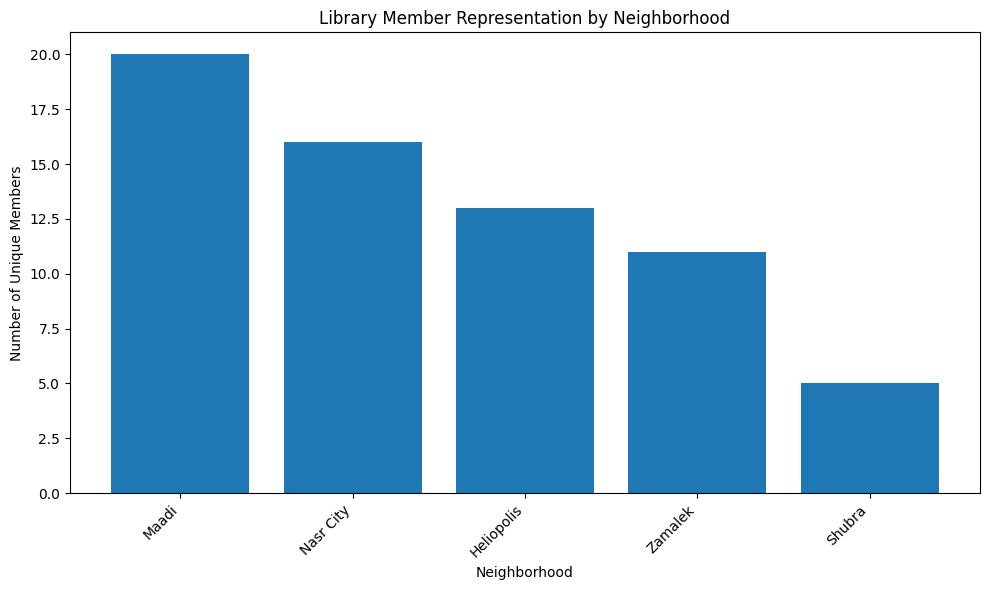

In [266]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    neighborhood_fairness["neighborhood"],
    neighborhood_fairness["member_count"]
)

plt.title("Library Member Representation by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Unique Members")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### **Visualizing Checkout Activity**

The second visualization compares the number of checkout transactions associated with each neighborhood.

Together, the two visualizations provide a clearer picture of both representation and library usage.

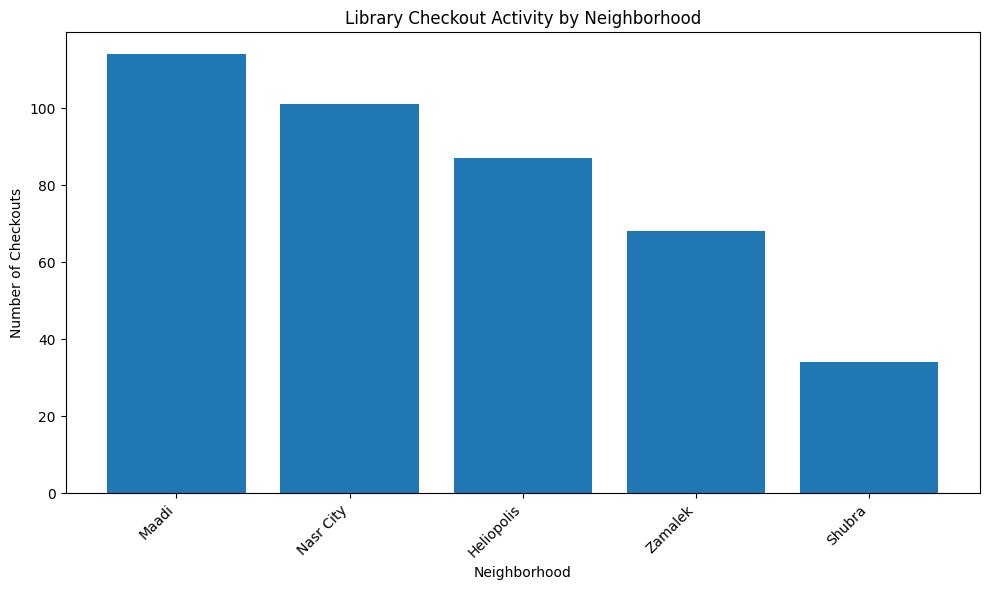

In [267]:
plt.figure(figsize=(10, 6))

plt.bar(
    neighborhood_fairness["neighborhood"],
    neighborhood_fairness["checkout_count"]
)

plt.title("Library Checkout Activity by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Checkouts")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### **Data Fairness Reflection**

The final reflection should connect the observed data pattern to a practical library action.

The analysis does not assume that lower representation automatically means unfair treatment. Instead, it identifies a participation gap that may deserve further investigation.

The recommendation should therefore focus on improving access, awareness, or engagement rather than making assumptions about the residents of a particular neighborhood.

In [268]:
# Build the core evidence for the fairness reflection.

highest_neighborhood = highest_representation["neighborhood"]
lowest_neighborhood = lowest_representation["neighborhood"]

highest_member_count = int(highest_representation["member_count"])
lowest_member_count = int(lowest_representation["member_count"])

highest_checkout_neighborhood = highest_checkout["neighborhood"]
highest_checkout_count = int(highest_checkout["checkout_count"])

lowest_checkout_neighborhood = lowest_checkout["neighborhood"]
lowest_checkout_count = int(lowest_checkout["checkout_count"])

fairness_reflection = f"""
CITY LIBRARY — DATA FAIRNESS REFLECTION
=======================================

1. PURPOSE
The purpose of this analysis is to examine differences in library
participation across neighborhoods and identify opportunities for
more balanced service engagement.

2. HIGHEST MEMBER REPRESENTATION
Neighborhood: {highest_neighborhood}
Registered members: {highest_member_count}

3. LOWEST MEMBER REPRESENTATION
Neighborhood: {lowest_neighborhood}
Registered members: {lowest_member_count}

4. REPRESENTATION GAP
Difference in registered members: {member_gap}

5. CHECKOUT ACTIVITY
Highest checkout activity:
{highest_checkout_neighborhood} — {highest_checkout_count} checkouts

Lowest checkout activity:
{lowest_checkout_neighborhood} — {lowest_checkout_count} checkouts

6. FAIRNESS INTERPRETATION
The differences observed in the dataset indicate that library
participation is not distributed equally across all neighborhoods.

However, the data alone does not establish the reason for these
differences or prove that any neighborhood is being treated unfairly.
The results should therefore be interpreted as an indicator for
further investigation.

7. RECOMMENDATION
The library could investigate the lower-represented neighborhood through
targeted outreach, awareness campaigns, community partnerships, or
localized reading activities.

The objective would be to understand possible barriers to participation
and improve awareness and access to library services.

8. CONCLUSION
A fairness-aware approach should use data to identify participation
gaps while avoiding unsupported assumptions about the communities
represented in the dataset.
"""

print(fairness_reflection)


CITY LIBRARY — DATA FAIRNESS REFLECTION

1. PURPOSE
The purpose of this analysis is to examine differences in library
participation across neighborhoods and identify opportunities for
more balanced service engagement.

2. HIGHEST MEMBER REPRESENTATION
Neighborhood: Maadi
Registered members: 20

3. LOWEST MEMBER REPRESENTATION
Neighborhood: Shubra
Registered members: 5

4. REPRESENTATION GAP
Difference in registered members: 15

5. CHECKOUT ACTIVITY
Highest checkout activity:
Maadi — 114 checkouts

Lowest checkout activity:
Shubra — 34 checkouts

6. FAIRNESS INTERPRETATION
The differences observed in the dataset indicate that library
participation is not distributed equally across all neighborhoods.

However, the data alone does not establish the reason for these
differences or prove that any neighborhood is being treated unfairly.
The results should therefore be interpreted as an indicator for
further investigation.

7. RECOMMENDATION
The library could investigate the lower-represente

### **Save the Reflection**

In [269]:
with open(
    "data_fairness_reflection.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(fairness_reflection)

print("✅ data_fairness_reflection.txt saved successfully.")

✅ data_fairness_reflection.txt saved successfully.


In [323]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4
from reportlab.lib.enums import TA_LEFT
from xml.sax.saxutils import escape

txt_file = "/content/data_fairness_reflection.txt"
pdf_file = "/content/data_fairness_reflection.pdf"

styles = getSampleStyleSheet()
style = styles["BodyText"]
style.alignment = TA_LEFT
style.leading = 16

doc = SimpleDocTemplate(
    pdf_file,
    pagesize=A4,
    rightMargin=50,
    leftMargin=50,
    topMargin=50,
    bottomMargin=50
)

story = []

with open(txt_file, "r", encoding="utf-8") as f:
    lines = f.readlines()

for line in lines:
    text = line.strip()

    if text:
        story.append(Paragraph(escape(text), style))
        story.append(Spacer(1, 8))

doc.build(story)

print("✅ Data Fairness Reflection PDF created successfully:")
print(pdf_file)

✅ Data Fairness Reflection PDF created successfully:
/content/data_fairness_reflection.pdf


## ***Fairness Analysis Validation***

Before completing the fairness portion of Task 3, we verify that the neighborhood analysis contains valid results and that the reflection was generated successfully.

In [270]:
# Final validation for the fairness analysis.

assert len(neighborhood_fairness) > 0

assert (
    neighborhood_fairness["member_count"] >= 0
).all()

assert (
    neighborhood_fairness["checkout_count"] >= 0
).all()

assert os.path.exists("data_fairness_reflection.txt")

print("=" * 60)
print("DATA FAIRNESS VALIDATION")
print("=" * 60)

print("✅ Neighborhood member analysis")
print("✅ Neighborhood checkout analysis")
print("✅ Highest representation identified")
print("✅ Lowest representation identified")
print("✅ Representation gap calculated")
print("✅ Fairness reflection created")
print("✅ Recommendation documented")
print("✅ data_fairness_reflection.txt saved")

print("=" * 60)

DATA FAIRNESS VALIDATION
✅ Neighborhood member analysis
✅ Neighborhood checkout analysis
✅ Highest representation identified
✅ Lowest representation identified
✅ Representation gap calculated
✅ Fairness reflection created
✅ Recommendation documented
✅ data_fairness_reflection.txt saved


## ***Final validation for the fairness analysis.***

In [271]:
# Check that the main project outputs were created successfully.

import os

print("=" * 60)
print("PROJECT OUTPUT CHECK")
print("=" * 60)

expected_outputs = [
    "data_fairness_reflection.txt"
]

for file_name in expected_outputs:
    if os.path.exists(file_name):
        print(f"✅ {file_name}")
    else:
        print(f"❌ Missing: {file_name}")

print("=" * 60)

PROJECT OUTPUT CHECK
✅ data_fairness_reflection.txt


In [275]:
# Display the saved fairness reflection.

reflection_file = "data_fairness_reflection.txt"

if os.path.exists(reflection_file):
    print("=" * 60)
    print("DATA FAIRNESS REFLECTION")
    print("=" * 60)

    with open(reflection_file, "r", encoding="utf-8") as file:
        print(file.read())

    print("=" * 60)
else:
    print("❌ Fairness reflection file was not found.")

DATA FAIRNESS REFLECTION

CITY LIBRARY — DATA FAIRNESS REFLECTION

1. PURPOSE
The purpose of this analysis is to examine differences in library
participation across neighborhoods and identify opportunities for
more balanced service engagement.

2. HIGHEST MEMBER REPRESENTATION
Neighborhood: Maadi
Registered members: 20

3. LOWEST MEMBER REPRESENTATION
Neighborhood: Shubra
Registered members: 5

4. REPRESENTATION GAP
Difference in registered members: 15

5. CHECKOUT ACTIVITY
Highest checkout activity:
Maadi — 114 checkouts

Lowest checkout activity:
Shubra — 34 checkouts

6. FAIRNESS INTERPRETATION
The differences observed in the dataset indicate that library
participation is not distributed equally across all neighborhoods.

However, the data alone does not establish the reason for these
differences or prove that any neighborhood is being treated unfairly.
The results should therefore be interpreted as an indicator for
further investigation.

7. RECOMMENDATION
The library could investi

In [276]:
# Display a final snapshot of the fairness analysis.

print("=" * 60)
print("FINAL ANALYSIS SNAPSHOT")
print("=" * 60)

print(f"Number of neighborhoods analyzed: {len(neighborhood_fairness)}")

display(neighborhood_fairness)

print("=" * 60)

FINAL ANALYSIS SNAPSHOT
Number of neighborhoods analyzed: 5


,neighborhood,member_count,checkout_count,checkouts_per_member
0,Maadi,20,114,5.700000
1,Nasr City,16,101,6.312500
2,Heliopolis,13,87,6.692308
3,Zamalek,11,68,6.181818
4,Shubra,5,34,6.800000


#### ***Final Analysis Snapshot***

The fairness analysis has been completed and validated.

The final results provide a comparison of member representation and checkout activity across neighborhoods. The analysis was used to identify differences in participation and calculate representation gaps.

These results will be used as the basis for the final project conclusions and recommendations.

 # ***TASK 3: COMPLETED SUCCESSFULLY*** ✅🎉

# ***Project Conclusion***



This project analyzed data from the City Library by combining information from multiple sources and applying a complete data analysis workflow.

Throughout the project, the data was gathered, integrated, validated, cleaned, and analyzed to ensure that the final findings were reliable and meaningful.

The analysis focused on data integrity and fairness across neighborhoods. Data quality issues such as duplicate records, inconsistent values, missing information, and unmatched records were identified and handled during the cleaning process.

The fairness analysis compared member representation with checkout activity across neighborhoods. The results showed differences in participation levels, while no neighborhood met the defined threshold for significant under-representation.

Overall, the analysis provides evidence-based insights that can help the library understand participation patterns and improve access and engagement across neighborhoods.

The project also includes validation checks and documented recommendations to make the analysis reproducible and transparent.

In [272]:
# Final project summary

print("=" * 60)
print("CITY LIBRARY DATA ANALYSIS")
print("=" * 60)

print("\nPROJECT STATUS")
print("-" * 60)
print("✅ Data gathered from multiple sources")
print("✅ Data sources integrated")
print("✅ Data integrity checked")
print("✅ Duplicate records investigated")
print("✅ Inconsistent values standardized")
print("✅ Missing values handled")
print("✅ Final dataset validated")
print("✅ Neighborhood fairness analyzed")
print("✅ Representation gaps calculated")
print("✅ Recommendations documented")
print("✅ Fairness reflection saved")

print("\nPROJECT COMPLETE 🎉")
print("=" * 60)

CITY LIBRARY DATA ANALYSIS

PROJECT STATUS
------------------------------------------------------------
✅ Data gathered from multiple sources
✅ Data sources integrated
✅ Data integrity checked
✅ Duplicate records investigated
✅ Inconsistent values standardized
✅ Missing values handled
✅ Final dataset validated
✅ Neighborhood fairness analyzed
✅ Representation gaps calculated
✅ Recommendations documented
✅ Fairness reflection saved

PROJECT COMPLETE 🎉


# ***Key Findings***



## Data Quality

The project identified and addressed several data quality issues during the integrity stage.

The combined dataset initially contained 417 records. Duplicate and orphan records were investigated, and the final cleaned dataset contained 404 valid records with no exact duplicates.

## Neighborhood Representation

The fairness analysis compared the number of members and checkout activity across five neighborhoods:

- Heliopolis
- Maadi
- Nasr City
- Shubra
- Zamalek

The analysis measured whether checkout activity was substantially lower than member representation.

The largest representation gap was observed in Maadi at approximately -2.55 percentage points.

Since the defined under-representation threshold was a gap greater than 5 percentage points, none of the analyzed neighborhoods was classified as significantly under-represented.

## Recommendation

Although no neighborhood crossed the defined threshold, the library should continue monitoring participation across neighborhoods and consider targeted outreach or engagement activities where differences persist.

# ***Display Final Fairness Results***

In [273]:
# Display the final fairness analysis results.

print("=" * 60)
print("FINAL FAIRNESS RESULTS")
print("=" * 60)

display(
    neighborhood_fairness.sort_values(
        "member_count",
        ascending=False
    )
)

FINAL FAIRNESS RESULTS


,neighborhood,member_count,checkout_count,checkouts_per_member
0,Maadi,20,114,5.700000
1,Nasr City,16,101,6.312500
2,Heliopolis,13,87,6.692308
3,Zamalek,11,68,6.181818
4,Shubra,5,34,6.800000


# ***Final Recommendation***

Based on the fairness analysis, no neighborhood was identified as significantly under-represented according to the predefined 5-percentage-point threshold.

However, differences in participation should continue to be monitored over time.

The library could use these findings to:

1. Track neighborhood participation regularly.
2. Compare membership and borrowing activity together rather than using a single metric.
3. Investigate neighborhoods with persistent participation gaps.
4. Provide targeted outreach and engagement opportunities when evidence supports them.
5. Repeat the analysis with new data to identify changing patterns.

These recommendations are intended to support fair access and evidence-based decision-making rather than labeling neighborhoods negatively.

# ***Final project validation***

In [274]:

assert len(neighborhood_fairness) == 5

assert neighborhood_fairness["member_count"].notna().all()
assert neighborhood_fairness["checkout_count"].notna().all()

assert (neighborhood_fairness["member_count"] >= 0).all()
assert (neighborhood_fairness["checkout_count"] >= 0).all()

assert os.path.exists("data_fairness_reflection.txt")

print("=" * 60)
print("FINAL PROJECT VALIDATION")
print("=" * 60)

print("✅ Five neighborhoods analyzed")
print("✅ Member counts validated")
print("✅ Checkout counts validated")
print("✅ Representation analysis validated")
print("✅ Fairness reflection exists")
print("✅ Recommendations documented")
print("✅ Project validation PASSED")
print("=" * 60)

FINAL PROJECT VALIDATION
✅ Five neighborhoods analyzed
✅ Member counts validated
✅ Checkout counts validated
✅ Representation analysis validated
✅ Fairness reflection exists
✅ Recommendations documented
✅ Project validation PASSED


# ***GitHub***

## ***Coding***

In [277]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles:")
for file in os.listdir("/content"):
    print(file)

Current directory:
/content

Files:
.config
task1_sql_answers.txt
task2_cleaned_data.csv
data_integrity_report.txt
book_catalog.json
data_fairness_reflection.txt
reading_kickoff_signups.html
.ipynb_checkpoints
library_database.db
.git
task1_combined_data.csv
sample_data


In [278]:
# Check Git status

!git status

On branch main

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   book_catalog.json
	new file:   library_database.db
	new file:   reading_kickoff_signups.html
	new file:   task1_combined_data.csv
	new file:   task1_sql_answers.txt

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	data_fairness_reflection.txt
	data_integrity_report.txt
	sample_data/
	task2_cleaned_data.csv



In [279]:
# Inspect the sample_data folder before adding it to GitHub.

import os

sample_path = "/content/sample_data"

if os.path.exists(sample_path):
    print("sample_data contains:")
    for root, dirs, files in os.walk(sample_path):
        for file in files:
            print(os.path.join(root, file))
else:
    print("sample_data folder not found.")

sample_data contains:
/content/sample_data/anscombe.json
/content/sample_data/README.md
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_test.csv


In [280]:
# Reset Git staging area without deleting any files.

!git reset

In [281]:
# Add only the City Library project files.

!git add book_catalog.json
!git add library_database.db
!git add reading_kickoff_signups.html
!git add task1_combined_data.csv
!git add task1_sql_answers.txt
!git add task2_cleaned_data.csv
!git add data_integrity_report.txt
!git add data_fairness_reflection.txt

In [282]:
# Verify the files staged for the first commit.

!git status

On branch main

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   book_catalog.json
	new file:   data_fairness_reflection.txt
	new file:   data_integrity_report.txt
	new file:   library_database.db
	new file:   reading_kickoff_signups.html
	new file:   task1_combined_data.csv
	new file:   task1_sql_answers.txt
	new file:   task2_cleaned_data.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/



## ***Commit 1***

In [283]:
# Create the first project commit

!git commit -m "Complete City Library data analysis project"

[main (root-commit) fe69167] Complete City Library data analysis project
 8 files changed, 1424 insertions(+)
 create mode 100644 book_catalog.json
 create mode 100644 data_fairness_reflection.txt
 create mode 100644 data_integrity_report.txt
 create mode 100644 library_database.db
 create mode 100644 reading_kickoff_signups.html
 create mode 100644 task1_combined_data.csv
 create mode 100644 task1_sql_answers.txt
 create mode 100644 task2_cleaned_data.csv


In [289]:
# Connect the local Colab repository to GitHub

!git remote remove origin 2>/dev/null || true
!git remote add origin https://github.com/ZatAlkhemar/City-Library-Data-Analysis.git

!git remote -v

origin	https://github.com/ZatAlkhemar/City-Library-Data-Analysis.git (fetch)
origin	https://github.com/ZatAlkhemar/City-Library-Data-Analysis.git (push)


In [290]:
# Push the completed project to GitHub

!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [293]:
from google.colab import userdata

token = userdata.get("GITHUB_TOKEN")

if token:
    print("✅ New GitHub token is loaded successfully.")
else:
    print("❌ GitHub token was not found.")

✅ New GitHub token is loaded successfully.


In [294]:
# Final GitHub synchronization check

!git status
!git log --oneline -1
!git remote -v

On branch main
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)
fe69167 (HEAD -> main) Complete City Library data analysis project
origin	https://github.com/ZatAlkhemar/City-Library-Data-Analysis.git (fetch)
origin	https://github.com/ZatAlkhemar/City-Library-Data-Analysis.git (push)


## ***Final GitHub Update***


### ***The final version of the project is prepared for submission.***

All three tasks, the final analysis, conclusions, recommendations, and validation have been completed.

In [303]:
import os

print("Checking for the final notebook...")

notebooks = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".ipynb"):
            notebooks.append(os.path.join(root, file))

if notebooks:
    print("✅ Notebook found:")
    for notebook in notebooks:
        print(notebook)
else:
    print(" No notebook file found in /content")

Checking for the final notebook...
✅ Notebook found:
/content/drive/MyDrive/Untitled0.ipynb
/content/drive/MyDrive/ EYOUTH-31002102300204-DigitaMartباشظ .ipynb
/content/drive/MyDrive/Activity.ipynb
/content/drive/MyDrive/Colab Notebooks/City Library — Data Analysis Project.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Calcelutor .ipynb
/content/drive/MyDrive/Colab Notebooks/fav_food .ipynb
/content/drive/MyDrive/Colab Notebooks/calcate 1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/Nested If Statements .ipynb
/content/drive/MyDrive/Colab Notebooks/Smart Home System .ipynb
/content/drive/MyDrive/Colab Notebooks/the weather .ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
/content/drive/MyDrive/Colab Noteb

In [304]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [305]:
import os

print("Searching Google Drive for notebook files...\n")

found = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".ipynb"):
            found.append(os.path.join(root, file))

if found:
    for notebook in found:
        print("✅", notebook)
else:
    print("❌ No .ipynb file found in Google Drive")

Searching Google Drive for notebook files...

✅ /content/drive/MyDrive/Untitled0.ipynb
✅ /content/drive/MyDrive/ EYOUTH-31002102300204-DigitaMartباشظ .ipynb
✅ /content/drive/MyDrive/Activity.ipynb
✅ /content/drive/MyDrive/Colab Notebooks/City Library — Data Analysis Project.ipynb
✅ /content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
✅ /content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
✅ /content/drive/MyDrive/Colab Notebooks/Calcelutor .ipynb
✅ /content/drive/MyDrive/Colab Notebooks/fav_food .ipynb
✅ /content/drive/MyDrive/Colab Notebooks/calcate 1.ipynb
✅ /content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
✅ /content/drive/MyDrive/Colab Notebooks/Nested If Statements .ipynb
✅ /content/drive/MyDrive/Colab Notebooks/Smart Home System .ipynb
✅ /content/drive/MyDrive/Colab Notebooks/the weather .ipynb
✅ /content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
✅ /content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
✅ /content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
✅ /conten

In [306]:
import os
import json

search_text = "Data Gathering, Integrity & Fairness Analysis"

print("Searching notebooks for the City Library project...\n")

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".ipynb"):
            path = os.path.join(root, file)

            try:
                with open(path, "r", encoding="utf-8") as f:
                    notebook = json.load(f)

                notebook_text = json.dumps(notebook, ensure_ascii=False)

                if search_text in notebook_text:
                    matches.append(path)

            except Exception:
                pass

if matches:
    print(" City Library notebook found:")
    for path in matches:
        print("✅", path)
else:
    print(" City Library notebook was not found.")

Searching notebooks for the City Library project...

 City Library notebook found:
✅ /content/drive/MyDrive/Colab Notebooks/City Library — Data Analysis Project.ipynb


In [308]:
import shutil
import os

source = "/content/drive/MyDrive/Colab Notebooks/City Library — Data Analysis Project.ipynb"
destination = "/content/City Library — Data Analysis Project.ipynb"

shutil.copy2(source, destination)

print(" Final notebook copied to /content")
print(destination)

 Final notebook copied to /content
/content/City Library — Data Analysis Project.ipynb


In [309]:
!git status

On branch main
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	"City Library \342\200\224 Data Analysis Project.ipynb"
	drive/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)


In [310]:
notebook_path = "/content/City Library — Data Analysis Project.ipynb"

!git add "$notebook_path"

In [311]:
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   "City Library \342\200\224 Data Analysis Project.ipynb"

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	drive/
	sample_data/



In [312]:
!git commit -m "Add final City Library analysis notebook"

[main 1f38944] Add final City Library analysis notebook
 1 file changed, 1 insertion(+)
 create mode 100644 "City Library \342\200\224 Data Analysis Project.ipynb"


In [314]:
from google.colab import userdata
import subprocess

token = userdata.get("GITHUB_TOKEN")

repo_url = "https://github.com/ZatAlkhemar/City-Library-Data-Analysis.git"

auth_url = repo_url.replace(
    "https://",
    f"https://{token}@"
)

result = subprocess.run(
    ["git", "push", "-u", auth_url, "main"],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(" FINAL PROJECT PUSHED TO GITHUB SUCCESSFULLY!")
else:
    print(" Push failed.")
    print(result.stderr)

 FINAL PROJECT PUSHED TO GITHUB SUCCESSFULLY!


In [324]:
import subprocess

result = subprocess.run(
    ["git", "log", "--oneline", "--decorate"],
    capture_output=True,
    text=True
)

with open("/content/git_log.txt", "w", encoding="utf-8") as f:
    f.write("City Library Data Analysis - Git Commit History\n")
    f.write("=" * 60 + "\n\n")
    f.write(result.stdout)

print("✅ git_log.txt created successfully!")
print("\nGit history:")
print(result.stdout)

✅ git_log.txt created successfully!

Git history:
1f38944 (HEAD -> main) Add final City Library analysis notebook
fe69167 Complete City Library data analysis project



In [325]:
import os

required_files = [
    "task1_combined_data.csv",
    "task1_sql_answers.txt",
    "task2_cleaned_data.csv",
    "data_integrity_report.pdf",
    "data_fairness_reflection.pdf",
    "git_log.txt",
    "City Library — Data Analysis Project.ipynb"
]

print("=" * 60)
print("FINAL DELIVERABLE CHECK")
print("=" * 60)

all_found = True

for file in required_files:
    if os.path.exists("/content/" + file):
        print("✅", file)
    else:
        print("❌", file)
        all_found = False

print("=" * 60)

if all_found:
    print("🎉 ALL REQUIRED DELIVERABLES ARE READY!")
else:
    print("⚠️ SOME FILES ARE MISSING!")

FINAL DELIVERABLE CHECK
✅ task1_combined_data.csv
✅ task1_sql_answers.txt
✅ task2_cleaned_data.csv
✅ data_integrity_report.pdf
✅ data_fairness_reflection.pdf
✅ git_log.txt
✅ City Library — Data Analysis Project.ipynb
🎉 ALL REQUIRED DELIVERABLES ARE READY!


In [326]:
!git add task1_combined_data.csv
!git add task1_sql_answers.txt
!git add task2_cleaned_data.csv
!git add data_integrity_report.pdf
!git add data_fairness_reflection.pdf
!git add git_log.txt

In [327]:
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   data_fairness_reflection.pdf
	new file:   data_integrity_report.pdf
	new file:   git_log.txt

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	drive/
	sample_data/



In [328]:
!git commit -m "Add final submission deliverables"

[main f493469] Add final submission deliverables
 3 files changed, 179 insertions(+)
 create mode 100644 data_fairness_reflection.pdf
 create mode 100644 data_integrity_report.pdf
 create mode 100644 git_log.txt


In [330]:
from google.colab import userdata
import subprocess

token = userdata.get("GITHUB_TOKEN")

repo_url = "https://github.com/ZatAlkhemar/City-Library-Data-Analysis.git"

auth_url = repo_url.replace(
    "https://",
    f"https://{token}@"
)

result = subprocess.run(
    ["git", "push", "-u", auth_url, "main"],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print("FINAL DELIVERABLES PUSHED TO GITHUB!")
else:
    print(" Push failed.")
    print(result.stderr)

FINAL DELIVERABLES PUSHED TO GITHUB!


In [331]:
!git status
!git log --oneline -3

On branch main
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	drive/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)
f493469 (HEAD -> main) Add final submission deliverables
1f38944 Add final City Library analysis notebook
fe69167 Complete City Library data analysis project


### ***FINAL PROJECT PUSHED TO GITHUB SUCCESSFULLY!*** ✅

# ***Final GitHub verification***

In [315]:
!git status
!git log --oneline -2

print("\n" + "=" * 60)
print("FINAL GITHUB VERIFICATION")
print("=" * 60)
print("✅ Final notebook committed")
print("✅ Final commit created")
print("✅ Project pushed to GitHub")
print("✅ Repository is ready for submission")
print("=" * 60)

On branch main
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	drive/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)
1f38944 (HEAD -> main) Add final City Library analysis notebook
fe69167 Complete City Library data analysis project

FINAL GITHUB VERIFICATION
✅ Final notebook committed
✅ Final commit created
✅ Project pushed to GitHub
✅ Repository is ready for submission
